# SETTING UP ACCESS TO GITHUB (PRESERVED STATE) FOR EVERY NEW RUNTIME

In [10]:
from google.colab import userdata
import os

git_token = userdata.get('GIT_TOKEN')
git_username = "TalhaShoyo10"
repo_name = "CS-6304_PA0_28100131"
repo_url = f"https://{git_token}@github.com/{git_username}/{repo_name}.git"



if not os.path.exists(repo_name):
  !git clone {repo_url}
  print("Repo did not exist in local file system, cloned from github to initiate work on task.")
else:
  !git -C {repo_name} pull
  print("Repo already existed in local file system, pulled from github to catch up on any remote changes.")

Already up to date.
Repo already existed in local file system, pulled from github to catch up on any remote changes.


Imports and Setup

In [19]:
!pip install -q transformers

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
import json
import os
from transformers import ViTImageProcessor, ViTForImageClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# UNDERSTANDING ViT

Loading Pretrained ViT Model and Image Processor

In [12]:
#Using a small pretrained ViT (base, patch size 16, 224 resolution), pretrained on ImageNet-21k and fine-tuned on ImageNet-1k
checkpoint = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(checkpoint)
model = ViTForImageClassification.from_pretrained(checkpoint, output_attentions=True)
model = model.to(device)
model.eval()

print(f"Loaded checkpoint: {checkpoint}")
print(f"Patch size: {model.config.patch_size}, Image size: {model.config.image_size}")
print(f"Number of labels: {model.config.num_labels}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loaded checkpoint: google/vit-base-patch16-224
Patch size: 16, Image size: 224
Number of labels: 1000


## Image Classification with the Pretrained ViT

Selecting Test Images

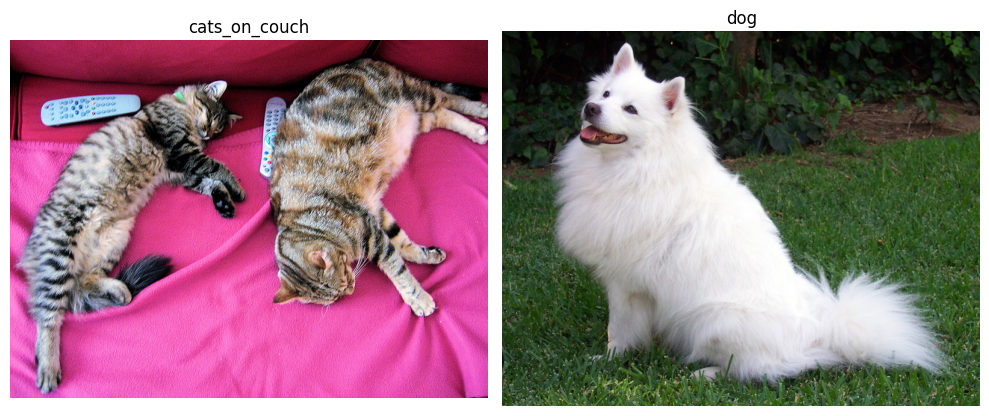

In [13]:
#Selecting a small set of test images from stable, publicly hosted URLs
#img_1: two cats on a couch (standard sample used in the HuggingFace ViT documentation)
#img_2: a dog (standard sample used in the PyTorch Hub tutorials)

image_urls = {
    "cats_on_couch": "http://images.cocodataset.org/val2017/000000039769.jpg",
    "dog": "https://github.com/pytorch/hub/raw/master/images/dog.jpg",
}

images = {}
for name, url in image_urls.items():
    img = Image.open(requests.get(url, stream=True).raw).convert("RGB")
    images[name] = img

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
if len(images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

Running Inference and Recording Top-1 Predictions

In [14]:
predictions = {}

for name, img in images.items():
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    top1_prob, top1_idx = torch.max(probs, dim=-1)
    predicted_label = model.config.id2label[top1_idx.item()]

    predictions[name] = {
        "predicted_label": predicted_label,
        "confidence": top1_prob.item()
    }

    print(f"Image: {name}")
    print(f"Top-1 Prediction: {predicted_label} (confidence: {top1_prob.item():.4f})")
    print("")

Image: cats_on_couch
Top-1 Prediction: Egyptian cat (confidence: 0.9375)

Image: dog
Top-1 Prediction: Samoyed, Samoyede (confidence: 0.6960)



## Visualizing Patch Attention

Extracting the [CLS] Token's Attention to Patch Tokens from the Final Layer

In [15]:
def get_cls_attention_map(img, model, processor, device):
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    #outputs.attentions is a tuple of length num_layers, each of shape (batch, num_heads, seq_len, seq_len)
    final_layer_attn = outputs.attentions[-1]

    #Averaging over all attention heads in the final layer
    attn_avg_heads = final_layer_attn.mean(dim=1).squeeze(0)  # (seq_len, seq_len)

    #Row 0 corresponds to the [CLS] token; taking its attention to all patch tokens (excluding itself)
    cls_attention = attn_avg_heads[0, 1:]

    num_patches = cls_attention.shape[0]
    grid_size = int(num_patches ** 0.5)
    assert grid_size * grid_size == num_patches, "Number of patches is not a perfect square"

    attention_map = cls_attention.reshape(grid_size, grid_size).cpu().numpy()
    return attention_map, inputs

Overlaying the Attention Map on Each Image

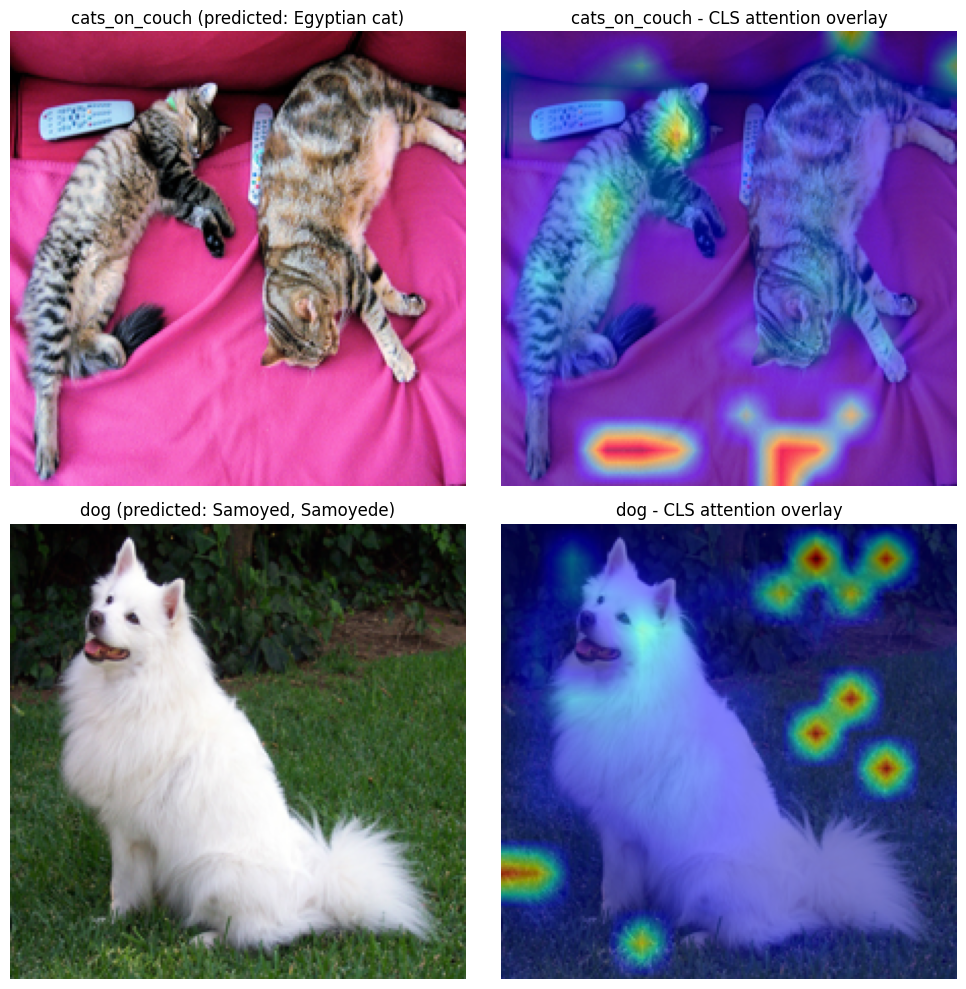

In [16]:
from scipy.ndimage import zoom

def overlay_attention(img, attention_map, alpha=0.5):
    #Resizing the low-resolution patch attention map up to the original image resolution
    img_resized = img.resize((224, 224))
    img_np = np.array(img_resized).astype(np.float32) / 255.0

    zoom_factor = 224 / attention_map.shape[0]
    attn_upsampled = zoom(attention_map, zoom_factor, order=1)
    attn_upsampled = (attn_upsampled - attn_upsampled.min()) / (attn_upsampled.max() - attn_upsampled.min() + 1e-8)

    return img_np, attn_upsampled

fig, axes = plt.subplots(len(images), 2, figsize=(10, 5 * len(images)))
alpha = 0.5

attention_maps = {}
for row, (name, img) in enumerate(images.items()):
    attn_map, _ = get_cls_attention_map(img, model, processor, device)
    attention_maps[name] = attn_map
    img_np, attn_upsampled = overlay_attention(img, attn_map)

    ax_left = axes[row, 0] if len(images) > 1 else axes[0]
    ax_right = axes[row, 1] if len(images) > 1 else axes[1]

    ax_left.imshow(img_np)
    ax_left.set_title(f"{name} (predicted: {predictions[name]['predicted_label']})")
    ax_left.axis("off")

    ax_right.imshow(img_np)
    ax_right.imshow(attn_upsampled, cmap="jet", alpha=alpha)
    ax_right.set_title(f"{name} - CLS attention overlay")
    ax_right.axis("off")

plt.tight_layout()
plt.savefig("CS-6304_PA0_28100131/results/task2_vit/attention_overlays.png", dpi=150)
plt.show()

# Patch masking

In [17]:
def mask_patches(inputs, patch_grid=14, mask_ratio=0.5, mode="random"):
    pixel_values = inputs["pixel_values"].clone()
    patch_size = 224 // patch_grid
    num_patches = patch_grid * patch_grid
    num_mask = int(num_patches * mask_ratio)

    if mode == "random":
        mask_idx = np.random.choice(num_patches, num_mask, replace=False)
    else:
        center = patch_grid // 2
        radius = int((num_mask ** 0.5) / 2) + 1
        coords = [(r, c) for r in range(center-radius, center+radius+1)
                          for c in range(center-radius, center+radius+1)
                          if 0 <= r < patch_grid and 0 <= c < patch_grid]
        mask_idx = [r*patch_grid+c for r, c in coords][:num_mask]

    for idx in mask_idx:
        r, c = idx // patch_grid, idx % patch_grid
        pixel_values[:, :, r*patch_size:(r+1)*patch_size, c*patch_size:(c+1)*patch_size] = 0

    inputs["pixel_values"] = pixel_values
    return inputs

masking_results = {}
for ratio in [0.25, 0.5]:
    for mode in ["random", "center"]:
        correct = 0
        for name, img in images.items():
            inputs = processor(images=img, return_tensors="pt").to(device)
            inputs = mask_patches(inputs, mask_ratio=ratio, mode=mode)
            with torch.no_grad():
                logits = model(**inputs).logits
            pred = model.config.id2label[logits.argmax(-1).item()]
            correct += int(pred == predictions[name]["predicted_label"])
        acc = correct / len(images)
        masking_results[f"{mode}_{int(ratio*100)}pct"] = acc
        print(f"{mode} masking, {int(ratio*100)}%: prediction retained {acc*len(images):.0f}/{len(images)}")

print(masking_results)

random masking, 25%: prediction retained 2/2
center masking, 25%: prediction retained 1/2
random masking, 50%: prediction retained 2/2
center masking, 50%: prediction retained 1/2
{'random_25pct': 1.0, 'center_25pct': 0.5, 'random_50pct': 1.0, 'center_50pct': 0.5}


# CLS vs mean-pooled linear probe

In [20]:
from transformers import ViTModel

vit_backbone = ViTModel.from_pretrained(checkpoint).to(device)
vit_backbone.eval()

vit_transform = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
small_train = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=vit_transform),
    range(2000))
small_test = torch.utils.data.Subset(
    torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=vit_transform),
    range(500))
probe_train_loader = DataLoader(small_train, batch_size=32, shuffle=True)
probe_test_loader = DataLoader(small_test, batch_size=32, shuffle=False)

def extract_features(loader, pooling):
    feats, labs = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out = vit_backbone(pixel_values=imgs).last_hidden_state
            f = out[:,0] if pooling == "cls" else out[:,1:].mean(dim=1)
            feats.append(f.cpu())
            labs.append(lbls)
    return torch.cat(feats), torch.cat(labs)

probe_results = {}
for pooling in ["cls", "mean"]:
    Xtr, ytr = extract_features(probe_train_loader, pooling)
    Xte, yte = extract_features(probe_test_loader, pooling)
    probe = nn.Linear(Xtr.shape[1], 10).to(device)
    opt = optim.Adam(probe.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    for epoch in range(5):
        probe.train()
        for i in range(0, len(Xtr), 64):
            xb, yb = Xtr[i:i+64].to(device), ytr[i:i+64].to(device)
            opt.zero_grad(); loss = crit(probe(xb), yb); loss.backward(); opt.step()
    probe.eval()
    with torch.no_grad():
        acc = (probe(Xte.to(device)).argmax(-1).cpu() == yte).float().mean().item()
    probe_results[pooling] = acc
    print(f"{pooling} pooling probe accuracy: {acc:.4f}")

print(probe_results)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cls pooling probe accuracy: 0.9620
mean pooling probe accuracy: 0.9660
{'cls': 0.9620000123977661, 'mean': 0.9660000205039978}


Saving Results

In [25]:
vit_results = {
    "checkpoint": checkpoint,
    "predictions": predictions,
    "patch_grid_size": int(attention_maps[list(attention_maps.keys())[0]].shape[0]),
}

with open("CS-6304_PA0_28100131/results/task2_vit/vit_results.json", "w") as f:
    json.dump(vit_results, f, indent=2)

print("Results saved successfully !!")

Results saved successfully !!


Checking for Saved Files

In [26]:
print(os.listdir("CS-6304_PA0_28100131/results/task2_vit"))

['vit_results.json', 'attention_overlays.png']


Git Configuration

In [27]:
!git config --global user.email "thebenbat5@gmail.com"
!git config --global user.name "TalhaShoyo10"

Commiting work to Github

In [28]:
commit_message = "Task 2 - ViT classification and attention visualization, forgot to commit the final version with all subtasks"
!git -C {repo_name} add -A
!git -C {repo_name} commit -m "{commit_message}"
!git -C {repo_name} push https://{git_token}@github.com/{git_username}/{repo_name}.git main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
